In [1]:
import csv
import json
import re
import zipfile
from collections import Counter
from datetime import datetime
from pathlib import Path

import geopandas as gpd
import igraph
import matplotlib.pyplot as plt
import pandas as pd
from rapidfuzz import fuzz, process
from tqdm import tqdm

In [2]:
with open("processed-actual-outages.csv") as file:
    csv_reader = csv.DictReader(file)
    actual_data = list(csv_reader)

In [3]:
date_keys = ["OutDatetime", "MinTimeStamp", "MaxTimeStamp"]

for row in tqdm(actual_data):
    row["PTID"] = int(row["PTID"])
    row["Voltage"] = int(row["Voltage"])
    for key in date_keys:
        row[key] = datetime.strptime(row[key], "%Y-%m-%d %H:%M:%S")

actual_data[0]

100%|██████████| 74063/74063 [00:01<00:00, 60974.29it/s]


{'PTID': 26053,
 'Name': 'MOUNTAIN-SWANROAD_115_104-3',
 'OutDatetime': datetime.datetime(2005, 1, 1, 0, 0),
 'MinTimeStamp': datetime.datetime(2012, 9, 11, 11, 52, 17),
 'MaxTimeStamp': datetime.datetime(2013, 8, 8, 8, 37, 17),
 'Voltage': 115,
 'FirstBus': 'MOUNTAIN',
 'SecondBus': 'SWANROAD',
 'OutageType': 'Planned'}

In [4]:
our_bus_set = set(
    [row[key] for row in actual_data for key in ["FirstBus", "SecondBus"]]
)
our_bus_list = sorted(our_bus_set)

print(f"num vertices: {len(our_bus_set)}")

bus_name_to_index = {bus_name: i for i, bus_name in enumerate(our_bus_list)}
index_to_bus_name = {i: bus_name for i, bus_name in enumerate(our_bus_list)}
n = len(bus_name_to_index)
g = igraph.Graph(n=len(bus_name_to_index), directed=False)

edge_set = set()
for datum in actual_data:
    b1, b2 = datum["FirstBus"], datum["SecondBus"]
    b1_index, b2_index = bus_name_to_index[b1], bus_name_to_index[b2]
    edge_set.add((b1_index, b2_index))
g.add_edges(list(edge_set))

print(g.is_connected())

num vertices: 1376
True


In [ ]:
# export graph
g.write_pickle("res/outage_graph.pkl")

In [6]:
bus_name_to_index_path = Path("res/bus_name_to_index.json")
index_to_bus_name_path = Path("res/index_to_bus_name.json")

bus_name_to_index_path.write_text(json.dumps(bus_name_to_index, indent=4))
index_to_bus_name_path.write_text(json.dumps(index_to_bus_name, indent=4))

31916

In [7]:
def preprocess_station_name(name: str) -> str:
    """
    Normalize compact station names such as:
    'E__SHORE' -> 'East Shore'
    'SCOV RCK' -> 'Scov Rock'
    'COMMACK_' -> 'Commack'

    Rules:
    - replace underscores with spaces
    - collapse repeated spaces
    - strip leading/trailing spaces
    - expand standalone direction letters:
        N -> North, S -> South, E -> East, W -> West
    - title-case the result
    """
    if not isinstance(name, str):
        raise TypeError("name must be a string")

    # Replace underscores with spaces
    s = name.replace("_", " ")

    # Collapse multiple spaces and strip
    s = re.sub(r"\s+", " ", s).strip()

    # Expand standalone cardinal directions
    direction_map = {
        "N.": "North",
        "S.": "South",
        "E.": "East",
        "W.": "West",
    }

    words = s.split()
    words = [direction_map.get(word, word) for word in words]

    # Title-case each word
    s = " ".join(words).title()

    return s

# find lat-long (Run once and manually edit)

In [8]:
match_path = Path("res/station_matches.csv")
ZIP_PATH = Path("res/new-york-260311-free.shp.zip")

In [9]:
def normalize_for_match(s: str) -> str:
    """
    Stronger normalization for fuzzy matching.
    """
    s = s.lower().strip()
    s = s.replace("_", " ")
    s = re.sub(r"\b(north|south|east|west)\b", "", s)
    s = re.sub(r"\b(n|s|e|w)\b", "", s)
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def list_zip_shapefiles(zip_path: Path):
    with zipfile.ZipFile(zip_path) as zf:
        return [n for n in zf.namelist() if n.endswith(".shp")]


# 1) Inspect zip contents
shp_files = list_zip_shapefiles(ZIP_PATH)
print("Shapefiles inside zip:")
for shp in shp_files:
    print(" -", shp)


# 2) Load candidate layers
#
# For Geofabrik/OpenStreetMap exports, these are often the most useful
# for place-name matching:
#   - gis_osm_places_free_1.shp
#   - gis_osm_pois_free_1.shp
#
# Adjust these names after you inspect `shp_files`.
candidate_layers = [
    shp for shp in shp_files if "places" in shp.lower() or "pois" in shp.lower()
]

print("\nCandidate layers:")
for shp in candidate_layers:
    print(" -", shp)

gdfs = []
for shp in candidate_layers:
    gdf = gpd.read_file(f"zip://{ZIP_PATH}!{shp}")
    gdf["__source_layer"] = shp
    gdfs.append(gdf)

if not gdfs:
    raise RuntimeError(
        "No candidate shapefiles found. Inspect the zip contents manually."
    )

candidates = pd.concat(gdfs, ignore_index=True)

print("\nColumns:")
print(candidates.columns.tolist())


# 3) Keep rows that have a name and point geometry
if "name" not in candidates.columns:
    raise RuntimeError("No 'name' column found in candidate layers.")

candidates = candidates[candidates["name"].notna()].copy()
candidates = candidates[candidates.geometry.notna()].copy()

# Reproject to lat/lon if needed
if candidates.crs is not None and candidates.crs.to_epsg() != 4326:
    candidates = candidates.to_crs(epsg=4326)

# Extract representative lat/lon
# If geometry is not a point, centroid gives a usable approximate coordinate.
candidates["lon"] = candidates.geometry.centroid.x
candidates["lat"] = candidates.geometry.centroid.y

# Build normalized match keys
candidates["name_clean"] = candidates["name"].astype(str).map(normalize_for_match)

# Drop empty names after normalization
candidates = candidates[candidates["name_clean"] != ""].copy()

# Deduplicate candidate names while preserving first occurrence
candidate_name_map = candidates.drop_duplicates(subset=["name_clean"]).set_index(
    "name_clean"
)

candidate_keys = candidate_name_map.index.tolist()


# 4) Match your station names to shapefile names
rows = []
for bus_name in tqdm(our_bus_list):
    query = normalize_for_match(preprocess_station_name(bus_name))

    if not query:
        rows.append(
            {
                "raw_name": bus_name,
                "clean_name": query,
                "matched_name": None,
                "score": None,
                "lat": None,
                "lon": None,
                "source_layer": None,
            }
        )
        continue

    best = process.extractOne(
        query,
        candidate_keys,
        scorer=fuzz.WRatio,
    )

    if best is None:
        rows.append(
            {
                "raw_name": bus_name,
                "clean_name": query,
                "matched_name": None,
                "score": None,
                "lat": None,
                "lon": None,
                "source_layer": None,
            }
        )
        continue

    matched_key, score, _ = best
    rec = candidate_name_map.loc[matched_key]

    rows.append(
        {
            "raw_name": bus_name,
            "clean_name": query,
            "matched_name": rec["name"],
            "score": score,
            "lat": rec["lat"],
            "lon": rec["lon"],
            "source_layer": rec["__source_layer"],
        }
    )

results = pd.DataFrame(rows)

print("\nMatch results:")
print(results.sort_values(["score", "raw_name"], ascending=[False, True]))

# Save for manual review
results.to_csv(match_path, index=False)

Shapefiles inside zip:
 - gis_osm_buildings_a_free_1.shp
 - gis_osm_landuse_a_free_1.shp
 - gis_osm_natural_a_free_1.shp
 - gis_osm_natural_free_1.shp
 - gis_osm_places_a_free_1.shp
 - gis_osm_places_free_1.shp
 - gis_osm_pofw_a_free_1.shp
 - gis_osm_pofw_free_1.shp
 - gis_osm_pois_a_free_1.shp
 - gis_osm_pois_free_1.shp
 - gis_osm_railways_free_1.shp
 - gis_osm_roads_free_1.shp
 - gis_osm_traffic_a_free_1.shp
 - gis_osm_traffic_free_1.shp
 - gis_osm_transport_a_free_1.shp
 - gis_osm_transport_free_1.shp
 - gis_osm_water_a_free_1.shp
 - gis_osm_waterways_free_1.shp

Candidate layers:
 - gis_osm_places_a_free_1.shp
 - gis_osm_places_free_1.shp
 - gis_osm_pois_a_free_1.shp
 - gis_osm_pois_free_1.shp

Columns:
['osm_id', 'code', 'fclass', 'population', 'name', 'geometry', '__source_layer']


/tmp/ipykernel_114136/2959217943.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  candidates["lon"] = candidates.geometry.centroid.x
/tmp/ipykernel_114136/2959217943.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  candidates["lat"] = candidates.geometry.centroid.y
100%|██████████| 1376/1376 [00:50<00:00, 27.16it/s]


Match results:
      raw_name clean_name                    matched_name  score        lat  \
12    ADAMS___      adams                     North Adams  100.0  43.886173   
14    AFTON___      afton                     North Afton  100.0  42.267857   
23    ALBANY__     albany                     West Albany  100.0  42.683134   
35    ALTAMONT   altamont                        Altamont  100.0  42.700632   
36    AMAWALK_    amawalk                         Amawalk  100.0  41.288427   
...        ...        ...                             ...    ...        ...   
1372  YOUNG214   young214                               1   90.0  40.661206   
1373  ZIMMERM1   zimmerm1                               1   90.0  40.661206   
1374  ZIMMERM2   zimmerm2                               2   90.0  40.662021   
1375  __BELLOW     bellow                               l   90.0  40.770135   
849   NEWP_PS_    newp ps  PS 9 Sarah Smith Garnet School   85.5  40.678550   

            lon               sourc

In [10]:
unresolved = results[
    results["lat"].isna() | results["lon"].isna() | (results["score"].fillna(0) < 85)
].copy()

# all are resolved but they're not correctly matched

# find unresolved locations

In [11]:
with match_path.open() as file:
    csv_reader = csv.DictReader(file)
    match_csv = list(csv_reader)

In [12]:
match_csv[0]

{'raw_name': '01ARMSTR',
 'clean_name': '01armstr',
 'matched_name': '1',
 'score': '90.0',
 'lat': '40.66120559564611',
 'lon': '-73.97623289182391',
 'source_layer': 'gis_osm_pois_a_free_1.shp'}

In [13]:
match_counter = Counter([row["matched_name"] for row in match_csv])
match_counter

Counter({'A&W': 324,
         'l': 146,
         '1': 59,
         'C&N': 58,
         '2': 45,
         'T': 36,
         'West G': 29,
         'on': 28,
         '3': 18,
         '4': 10,
         '5': 9,
         'Rock West': 7,
         'B': 7,
         'D': 7,
         'U': 7,
         '6': 7,
         'West Park': 7,
         'West End': 6,
         'Union': 6,
         'South Hill': 5,
         'North Bay': 4,
         '7': 4,
         'Depew': 4,
         '8': 4,
         'Sun': 4,
         'West Alden': 3,
         'Batavia': 3,
         'West Kill': 3,
         'West Bergen': 3,
         'East Line': 3,
         'V': 3,
         'GRDN': 3,
         'Elwood': 3,
         'Essex': 3,
         'Glen': 3,
         'Hunt': 3,
         'Ridge': 3,
         'East Seneca': 3,
         'West Sweden': 3,
         'Akron': 2,
         'Berry & Berry': 2,
         'Ray': 2,
         'Brooklyn Grange': 2,
         'Buchanan': 2,
         'Chelsea': 2,
         'Cobb': 2,
         'Colto

In [14]:
for row in match_csv:
    row["count"] = match_counter[row["matched_name"]]

match_csv = sorted(match_csv, key=lambda row: (row["count"], row["matched_name"]))

In [15]:
match_path = Path("res/station_matches_2.csv")

results = pd.DataFrame(match_csv)
results.to_csv(match_path, index=False)

# resolve N/E/W/S/_ | A/B/_ stations

less than 700 locations would be resolved and there is out of time for this project.

# K-coreness measure

In [36]:
# load graph (and bus name mapping) if not already available
g = igraph.Graph.Read_Pickle("res/outage_graph.pkl")

coreness = g.coreness()
coreness_counter = Counter(coreness)
for i in range(1, 5):
    print(f"k-coreness: {i}\tnum_buses: {coreness_counter[i]}")

k-coreness: 1	num_buses: 318
k-coreness: 2	num_buses: 831
k-coreness: 3	num_buses: 220
k-coreness: 4	num_buses: 7


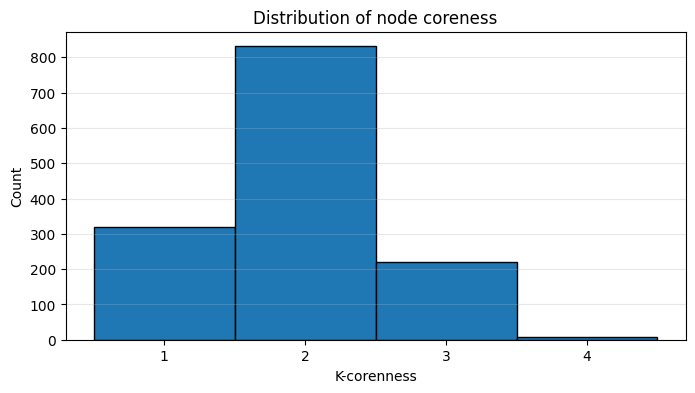

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(
    coreness,
    bins=range(min(coreness), max(coreness) + 2),
    align="left",
    edgecolor="black",
)
plt.xlabel("K-corenness")
plt.ylabel("Count")
plt.title("Distribution of node coreness")
plt.xticks(range(min(coreness), max(coreness) + 1))
plt.grid(axis="y", alpha=0.3)
plt.show()

In [33]:
# failures for each k-coreness set
coreness_df = pd.DataFrame(
    {
        "bus_index": range(len(coreness)),
        "bus_name": [index_to_bus_name[i] for i in range(len(coreness))],
        "coreness": coreness,
    }
)

print(coreness_df.head())

k_coreness_groups = {
    k: coreness_df.loc[coreness_df["coreness"] == k, "bus_name"].tolist()
    for k in range(1, 5)
}
k_coreness_groups

   bus_index  bus_name  coreness
0          0  01ARMSTR         2
1          1  01CABOT_         1
2          2  01DOUBS_         1
3          3  01FMARTN         1
4          4  01HARRIS         1


{1: ['01CABOT_',
  '01DOUBS_',
  '01FMARTN',
  '01HARRIS',
  '01HATFLD',
  '01WYLIE_',
  '01YUKON_',
  'AKWESSNE',
  'ALANBQ26',
  'ALANBQ28',
  'ALBION31',
  'ALLGNY_P',
  'AMENIA__',
  'ARROW PH',
  'ASC TAP_',
  'ASCUTNEY',
  'ASHFELDS',
  'ASTENRGY',
  'ASTORIA2',
  'AVENUE_A',
  'BALLSTON',
  'BARBEACH',
  'BARRE___',
  'BAY  1-4',
  'BAYWAY__',
  'BELLNGHM',
  'BELLVILE',
  'BENSHRST',
  'BERGEN 1',
  'BERLINVT',
  'BERRY_ST',
  'BETHPAGE',
  'BETHWEST',
  'BLUE_HIL',
  'BOSTJN21',
  'BOSTJN22',
  'BRANTFRD',
  'BRAYT PT',
  'BRENTWOD',
  'BROCKP74',
  'BROCKVLE',
  'BROOK_RD',
  'BRUNSWCK',
  'BUFFALRD',
  'BURD_STE',
  'CALEDJN5',
  'CALEDNIA',
  'CALVRTON',
  'CANTON__',
  'CARP HL_',
  'CARRCRCL',
  'CARRSCRN',
  'CATAR X1',
  'CATARQUI',
  'CEDARSHQ',
  'CEDARSUB',
  'CEDAR_OR',
  'CHATEAUG',
  'CHATHAM_',
  'CHELSEA_',
  'CHENIER_',
  'CHERRYST',
  'CHIPP TP',
  'CLOSTER_',
  'COBBLENY',
  'COLDSPRG',
  'COLUMH24',
  'COLUMH26',
  'COMERFRD',
  'COMFD DC',
  'COMMACK_',
  '

In [31]:
# map bus name -> coreness
coreness_map = dict(zip(coreness_df["bus_name"], coreness_df["coreness"]))

planned = Counter()
auto = Counter()

for row in actual_data:
    outage_type = str(row.get("OutageType", "")).strip().lower()
    for bus in (row["FirstBus"], row["SecondBus"]):
        if outage_type == "planned":
            planned[bus] += 1
        elif outage_type in ("auto", "automatic"):
            auto[bus] += 1

bus_failure_stats = {
    bus: {
        "coreness": coreness_map.get(bus),
        "planned_failures": planned[bus],
        "auto_failures": auto[bus],
    }
    for bus in our_bus_list
}

# inspect a few entries
bus_failure_stats

{'01ARMSTR': {'coreness': 2, 'planned_failures': 5, 'auto_failures': 1},
 '01CABOT_': {'coreness': 1, 'planned_failures': 9, 'auto_failures': 15},
 '01DOUBS_': {'coreness': 1, 'planned_failures': 14, 'auto_failures': 4},
 '01FMARTN': {'coreness': 1, 'planned_failures': 0, 'auto_failures': 5},
 '01HARRIS': {'coreness': 1, 'planned_failures': 0, 'auto_failures': 15},
 '01HATFLD': {'coreness': 1, 'planned_failures': 8, 'auto_failures': 9},
 '01WYLIE_': {'coreness': 1, 'planned_failures': 0, 'auto_failures': 22},
 '01YUKON_': {'coreness': 1, 'planned_failures': 23, 'auto_failures': 8},
 '04PERRY_': {'coreness': 2, 'planned_failures': 24, 'auto_failures': 9},
 '3 MILE I': {'coreness': 2, 'planned_failures': 0, 'auto_failures': 14},
 '49STREET': {'coreness': 3, 'planned_failures': 16, 'auto_failures': 116},
 'ACADEMY_': {'coreness': 2, 'planned_failures': 107, 'auto_failures': 3},
 'ADAMS___': {'coreness': 2, 'planned_failures': 30, 'auto_failures': 13},
 'ADIRNDCK': {'coreness': 3, 'planned

In [40]:
# k-coreness average failures
coreness_stats = []
planned_per_coreness, auto_per_coreness = [], []
for i in range(1, 5):
    for bus_name, value in bus_failure_stats.items():
        if value["coreness"] == i:
            planned_per_coreness.append(value["planned_failures"])
            auto_per_coreness.append(value["auto_failures"])
    total_planned_per_coreness = sum(planned_per_coreness)
    total_auto_per_coreness = sum(auto_per_coreness)
    result_dict = {
        "coreness": i,
        "total planned failures": total_planned_per_coreness,
        "total auto failures": total_auto_per_coreness,
        "average planned failues": total_planned_per_coreness / coreness_counter[i],
        "average auto failues": total_auto_per_coreness / coreness_counter[i],
    }
    coreness_stats.append(result_dict)
coreness_stats

[{'coreness': 1,
  'total planned failures': 4130,
  'total auto failures': 2497,
  'average planned failues': 12.9874213836478,
  'average auto failues': 7.852201257861635},
 {'coreness': 2,
  'total planned failures': 79076,
  'total auto failures': 12874,
  'average planned failues': 95.15764139590854,
  'average auto failues': 15.492178098676293},
 {'coreness': 3,
  'total planned failures': 127977,
  'total auto failures': 17271,
  'average planned failues': 581.7136363636364,
  'average auto failues': 78.50454545454545},
 {'coreness': 4,
  'total planned failures': 130752,
  'total auto failures': 17374,
  'average planned failues': 18678.85714285714,
  'average auto failues': 2482.0}]

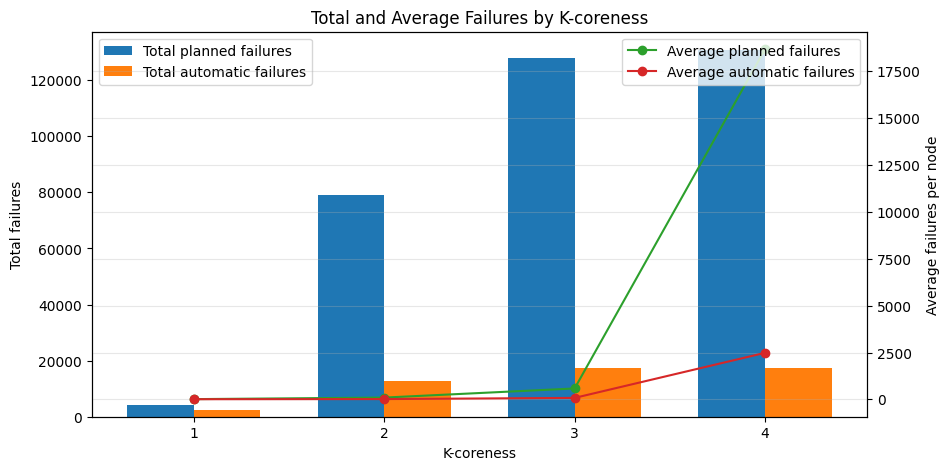

In [41]:
df_stats = pd.DataFrame(coreness_stats).set_index("coreness").sort_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

x = df_stats.index
width = 0.35

ax1.bar(
    x - width / 2,
    df_stats["total planned failures"],
    width,
    label="Total planned failures",
)
ax1.bar(
    x + width / 2,
    df_stats["total auto failures"],
    width,
    label="Total automatic failures",
)

ax1.set_xlabel("K-coreness")
ax1.set_ylabel("Total failures")
ax1.set_xticks(x)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(
    x,
    df_stats["average planned failues"],
    marker="o",
    label="Average planned failures",
    color="C2",
)
ax2.plot(
    x,
    df_stats["average auto failues"],
    marker="o",
    label="Average automatic failures",
    color="C3",
)
ax2.set_ylabel("Average failures per node")
ax2.legend(loc="upper right")

plt.title("Total and Average Failures by K-coreness")
plt.grid(axis="y", alpha=0.3)
plt.show()

# detect motifs